# Import libraries

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np 

# Loading the dataset 

In [2]:
df = pd.read_csv("train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Dataset size

In [3]:
df.shape

(1460, 81)

General Informations

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### Missing Values

In [4]:
df.isnull().sum().sort_values(ascending=False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Id                 0
dtype: int64

# First plot (target: house price)

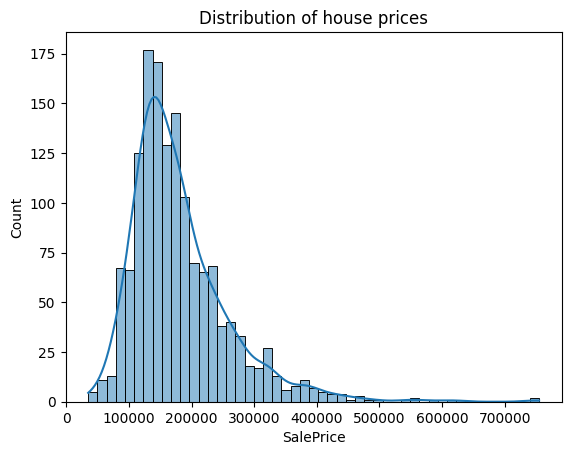

In [6]:
sns.histplot(df["SalePrice"], kde = True)
plt.title("Distribution of house prices")
plt.show()

In [7]:
y = df["SalePrice"]
X = df.drop("SalePrice",axis=1)

# Data Cleaning

In [8]:
# Percentuale valori mancanti
missing_ratio = X.isnull().mean().sort_values(ascending=False)
missing_ratio.head(20)

PoolQC          0.995205
MiscFeature     0.963014
Alley           0.937671
Fence           0.807534
MasVnrType      0.597260
FireplaceQu     0.472603
LotFrontage     0.177397
GarageCond      0.055479
GarageType      0.055479
GarageYrBlt     0.055479
GarageQual      0.055479
GarageFinish    0.055479
BsmtFinType2    0.026027
BsmtExposure    0.026027
BsmtFinType1    0.025342
BsmtCond        0.025342
BsmtQual        0.025342
MasVnrArea      0.005479
Electrical      0.000685
BedroomAbvGr    0.000000
dtype: float64

In [10]:
### If more than 40% of values are missing, the column is removed  
#to ensure data quality and improve model reliability.

In [11]:

cols_to_drop = missing_ratio[missing_ratio > 0.4].index
X = X.drop(cols_to_drop, axis=1)
print("Removed columns:", len(cols_to_drop))

Removed columns: 6


In [12]:
num_cols = X.select_dtypes(include=["int64","float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns
print("Numeric",len(num_cols))
print("Categoric",len(cat_cols))

Numeriche 37
Categoriche 37


In [13]:
X[num_cols] = X[num_cols].fillna(X[num_cols].median() )

In [14]:
X[cat_cols] = X[cat_cols].fillna("Missing")

In [15]:
X.isnull().sum().sum()

0

Encoding categorical variable

In [16]:

cat_cols = X.select_dtypes(include=["object"]).columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
X.shape


(1460, 240)

# Train/Test Split

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, 
test_size = 0.2, random_state = 42)

# Random Forest Model

In [18]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators =200, random_state = 42) 
model.fit(X_train, y_train)
predictions = model.predict(X_test)


In [19]:
# MAE (Mean Absolute Error)
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, predictions)
print("MAE:",mae)

MAE: 17615.393219178084


In [21]:
results = pd.DataFrame({"Real": y_test, "Predicted": predictions})
results.head(10)

,Real,Predicted
892,154500,140482.935
1105,325000,317714.890
413,115000,116844.875
522,159000,151047.520
1036,315500,324820.970
614,75500,84713.125
218,311500,210394.590
1160,146000,152351.710
649,84500,84586.080
887,135500,129865.450


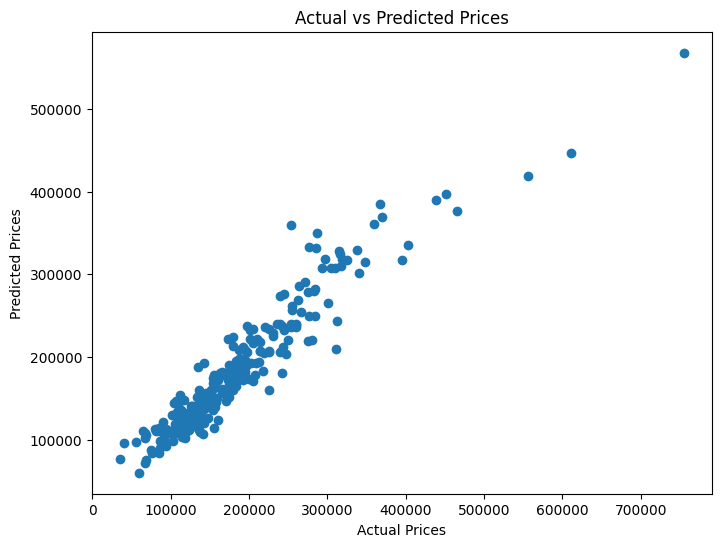

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Prices")

plt.show()

Now, let’s analyze which variables have the greatest impact on house prices.

In [23]:
importances = model.feature_importances_ 

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})
feature_importance = feature_importance.sort_values(by ="Importance", ascending = False)

feature_importance.head(10)

,Feature,Importance
4,OverallQual,0.558804
16,GrLivArea,0.122509
12,TotalBsmtSF,0.034056
14,2ndFlrSF,0.030708
13,1stFlrSF,0.029032
9,BsmtFinSF1,0.028483
3,LotArea,0.018261
27,GarageArea,0.015198
26,GarageCars,0.014878
6,YearBuilt,0.013397


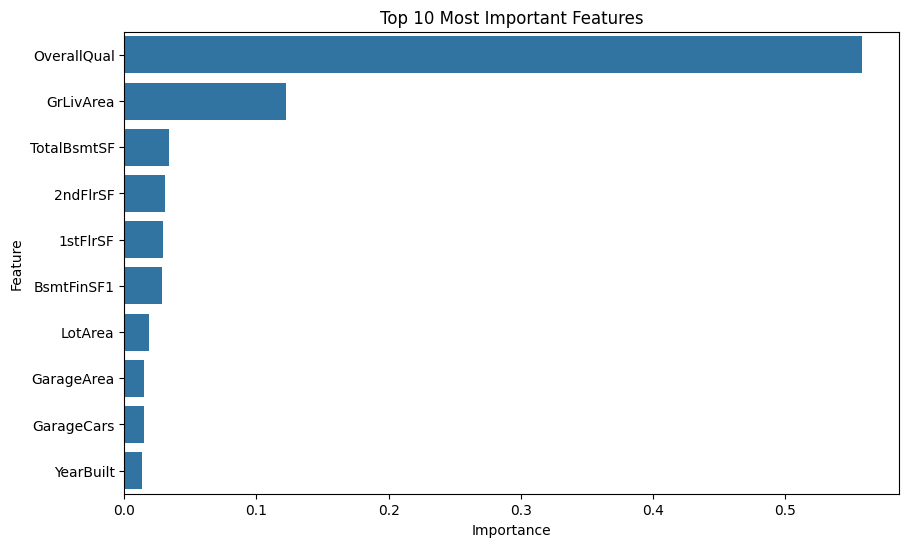

In [24]:
top_features = feature_importance.head(10)
plt.figure(figsize=(10,6))

sns.barplot(data=top_features, x="Importance", y="Feature")

plt.title("Top 10 Most Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

Insight: The model shows that overall house quality and living area are the most influential variables in determining house prices.

# Feature importance and new Random Forest Model 

1. We select the most important features.

In [27]:

top_cols = feature_importance.head(20)["Feature"]
X_reduced = X[top_cols]


2. Train/Test split: new dataset

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size = 0.2
                                                   , random_state = 42)

3. New Random Forest Model

In [29]:
model_reduced = RandomForestRegressor(n_estimators = 200, random_state = 42)

model_reduced.fit(X_train, y_train )

RandomForestRegressor(n_estimators=200, random_state=42)

4. Predictions

In [30]:
pred_reduced = model_reduced.predict(X_test)

5. Evaluation of the improved model

In [31]:
mae_reduced = mean_absolute_error(y_test, pred_reduced)
print(f"MAE (Reduced Feature Model): {mae_reduced}")

MAE (Reduced Feature Model): 18404.73551369863


6. Comparison with the original model

In [34]:
print("Original MAE:", mean_absolute_error(y_test, predictions))
print("Reduced MAE:", mae_reduced)

Original MAE: 17615.393219178084
Reduced MAE: 18404.73551369863


7. Comparison visualization

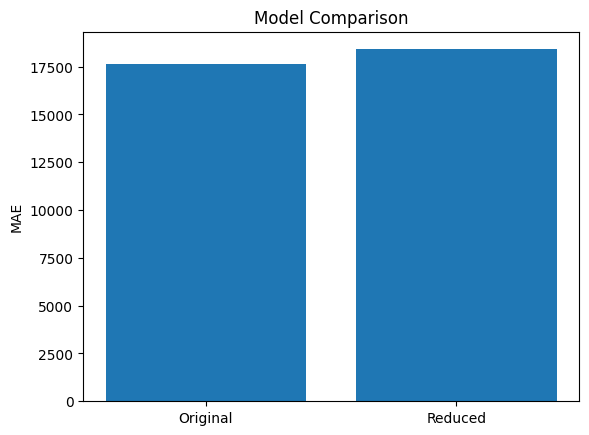

In [35]:
plt.bar(["Original", "Reduced"], [mean_absolute_error(y_test, predictions), 
                                  mae_reduced])

plt.title("Model Comparison")
plt.ylabel("MAE")

plt.show()